# RavenStack SaaS Product, Revenue & Churn Analysis
## Notebook 1: Data Cleaning & Exploratory Data Analysis

**Dataset:** RavenStack is a fully **synthetic** SaaS dataset created by **River @ Rivalytics**. It does not represent a real company or real customers - it was generated for analytics practice.

**Goal of this notebook:**
- Load the 5 raw CSV files
- Check shape, data types, missing values and duplicates
- Convert date columns and create a few simple derived columns
- Merge the tables into one account-level table for analysis
- Explore the data visually with Matplotlib / Seaborn

Libraries used: `pandas`, `numpy`, `matplotlib`, `seaborn` only (no ML libraries).

In [ ]:
import pandas as pdimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snssns.set_style('whitegrid')plt.rcParams['figure.dpi'] = 100RAW = '../data/raw/'

## 1. Load the raw data

In [ ]:
accounts = pd.read_csv(RAW+'ravenstack_accounts.csv', parse_dates=['signup_date'])subscriptions = pd.read_csv(RAW+'ravenstack_subscriptions.csv', parse_dates=['start_date','end_date'])feature_usage = pd.read_csv(RAW+'ravenstack_feature_usage.csv', parse_dates=['usage_date'])support_tickets = pd.read_csv(RAW+'ravenstack_support_tickets.csv', parse_dates=['submitted_at','closed_at'])churn_events = pd.read_csv(RAW+'ravenstack_churn_events.csv', parse_dates=['churn_date'])for name, df in [('accounts',accounts), ('subscriptions',subscriptions), ('feature_usage',feature_usage),                  ('support_tickets',support_tickets), ('churn_events',churn_events)]:    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

accounts: 500 rows, 10 columnssubscriptions: 5000 rows, 14 columnsfeature_usage: 25000 rows, 8 columnssupport_tickets: 2000 rows, 9 columnschurn_events: 600 rows, 9 columns

## 2. Inspect structure, data types and missing values

In [ ]:
accounts.info()

<class 'pandas.core.frame.DataFrame'>RangeIndex: 500 entries, 0 to 499Data columns (total 10 columns): account_id, account_name, industry, country, signup_date, referral_source, plan_tier, seats, is_trial, churn_flagdtypes: bool(2), datetime64[ns](1), int64(1), object(6)

In [ ]:
# Missing values across all 5 tablesfor name, df in [('accounts',accounts), ('subscriptions',subscriptions), ('feature_usage',feature_usage),                  ('support_tickets',support_tickets), ('churn_events',churn_events)]:    missing = df.isna().sum()    missing = missing[missing > 0]    print(f"--- {name} ---")    print(missing if len(missing) else "No missing values")    print()

--- accounts ---No missing values--- subscriptions ---end_date    4514dtype: int64--- feature_usage ---No missing values--- support_tickets ---satisfaction_score    825dtype: int64--- churn_events ---feedback_text    148dtype: int64

**Notes on missing values (these are expected, not data quality bugs):**
- `subscriptions.end_date` is missing for subscriptions that are still ongoing (no end date yet).
- `support_tickets.satisfaction_score` is missing when a customer never submitted a CSAT survey response.
- `churn_events.feedback_text` is missing when the customer didn't leave a free-text reason for churning.

We will **not** fill these in with fake values - they are left as `NaN` and handled with `.dropna()` or `.fillna(0)` only where it makes analytical sense (e.g. an account with zero usage events).

In [ ]:
# Duplicate rows and primary key uniqueness checksprint("Duplicate rows:")for name, df in [('accounts',accounts), ('subscriptions',subscriptions), ('feature_usage',feature_usage),                  ('support_tickets',support_tickets), ('churn_events',churn_events)]:    print(f"  {name}: {df.duplicated().sum()}")print()print("Primary key uniqueness:")print("  accounts.account_id unique:", accounts['account_id'].is_unique)print("  subscriptions.subscription_id unique:", subscriptions['subscription_id'].is_unique)print("  feature_usage.usage_id unique:", feature_usage['usage_id'].is_unique)print("  support_tickets.ticket_id unique:", support_tickets['ticket_id'].is_unique)print("  churn_events.churn_event_id unique:", churn_events['churn_event_id'].is_unique)

Duplicate rows:  accounts: 0  subscriptions: 0  feature_usage: 0  support_tickets: 0  churn_events: 0Primary key uniqueness:  accounts.account_id unique: True  subscriptions.subscription_id unique: True  feature_usage.usage_id unique: True  support_tickets.ticket_id unique: True  churn_events.churn_event_id unique: True

## 3. Checking table relationships

Foreign key checks - every child-table `account_id` / `subscription_id` should exist in its parent table.

In [ ]:
print("All subscriptions.account_id found in accounts:", subscriptions['account_id'].isin(accounts['account_id']).all())print("All feature_usage.subscription_id found in subscriptions:", feature_usage['subscription_id'].isin(subscriptions['subscription_id']).all())print("All support_tickets.account_id found in accounts:", support_tickets['account_id'].isin(accounts['account_id']).all())print("All churn_events.account_id found in accounts:", churn_events['account_id'].isin(accounts['account_id']).all())print()print("Subscriptions per account - summary:")print(subscriptions.groupby('account_id').size().describe())

All subscriptions.account_id found in accounts: TrueAll feature_usage.subscription_id found in subscriptions: TrueAll support_tickets.account_id found in accounts: TrueAll churn_events.account_id found in accounts: TrueSubscriptions per account - summary:count    500.000000mean      10.000000std        3.271300min        2.00000025%        7.00000050%       10.00000075%       12.000000max       19.000000dtype: float64

**Important data note:** each account has ~10 subscription records on average, not just one. This means `subscriptions` is a **history of subscription/billing periods** per account rather than a single row per account.

For "current" account-level metrics (like current MRR or current plan), we take **the subscription with the most recent `start_date`** for each account. This is a simple, explainable rule that a fresher can defend in an interview.

We also noticed that `accounts.plan_tier` (an account attribute) does not always match the plan tier on that account's latest subscription. This is a known quirk of this synthetic dataset - we call it out here and consistently use the **subscription-level plan_tier** whenever we talk about revenue by plan, since MRR is a subscription-level fact.

## 4. Derived columns and merging into one account-level table

In [ ]:
# Subscription duration in days (only meaningful for subscriptions that have ended)subscriptions['duration_days'] = (subscriptions['end_date'] - subscriptions['start_date']).dt.days# Latest subscription per account = the account's "current" plan / MRRlatest_sub = (subscriptions              .sort_values(['account_id','start_date','subscription_id'])              .groupby('account_id').tail(1)              .rename(columns={'plan_tier':'current_plan_tier','seats':'current_seats'}))accounts_enriched = accounts.merge(    latest_sub[['account_id','current_plan_tier','current_seats','mrr_amount','arr_amount',                'billing_frequency','auto_renew_flag']],    on='account_id', how='left')print(accounts_enriched.shape)accounts_enriched.head(3)

(500, 15)

In [ ]:
# Roll feature usage up from subscription level to account levelusage_acc = feature_usage.merge(subscriptions[['subscription_id','account_id']], on='subscription_id', how='left')usage_summary = usage_acc.groupby('account_id').agg(    total_usage_count=('usage_count','sum'),    avg_usage_count=('usage_count','mean'),    total_usage_duration_secs=('usage_duration_secs','sum'),    total_error_count=('error_count','sum'),    n_usage_events=('usage_id','count'),    n_features_used=('feature_name','nunique'),    beta_usage_events=('is_beta_feature','sum'),).reset_index()# Roll support tickets up to account levelticket_summary = support_tickets.groupby('account_id').agg(    n_tickets=('ticket_id','count'),    avg_resolution_hours=('resolution_time_hours','mean'),    avg_first_response_min=('first_response_time_minutes','mean'),    avg_satisfaction=('satisfaction_score','mean'),    n_escalations=('escalation_flag','sum'),).reset_index()master = accounts_enriched.merge(usage_summary, on='account_id', how='left')master = master.merge(ticket_summary, on='account_id', how='left')# Accounts with no usage/support activity get 0, not NaNfill_cols = ['total_usage_count','avg_usage_count','total_usage_duration_secs','total_error_count',             'n_usage_events','n_features_used','beta_usage_events','n_tickets','n_escalations']master[fill_cols] = master[fill_cols].fillna(0)master['status'] = np.where(master['churn_flag'] == True, 'Churned', 'Retained')print("Master account-level table:", master.shape)master.to_csv('../data/processed/master_account_table.csv', index=False)

Master account-level table: (500, 30)

## 5. Simple rule-based segmentation

We create two beginner-friendly segments using `pd.cut`/manual thresholds - **not** clustering algorithms:
- **Usage segment**: Low / Medium / High, based on tertiles of `total_usage_count`
- **MRR segment**: Low / Medium / High MRR, based on tertiles of `mrr_amount`

In [ ]:
q1, q2 = master['total_usage_count'].quantile([0.33, 0.66])master['usage_segment'] = pd.cut(master['total_usage_count'], bins=[-1, q1, q2, np.inf], labels=['Low','Medium','High'])m1, m2 = master['mrr_amount'].quantile([0.33, 0.66])master['mrr_segment'] = pd.cut(master['mrr_amount'], bins=[-1, m1, m2, np.inf], labels=['Low MRR','Medium MRR','High MRR'])print(master['usage_segment'].value_counts())print()print(master['mrr_segment'].value_counts())

usage_segmentHigh      170Low       165Medium    165Name: count, dtype: int64mrr_segmentHigh MRR      169Low MRR       168Medium MRR    163Name: count, dtype: int64

## 6. Exploratory Data Analysis (EDA)
Each chart below is chosen to answer a specific question - not created just to fill space.

**Q: How is MRR distributed across accounts?**

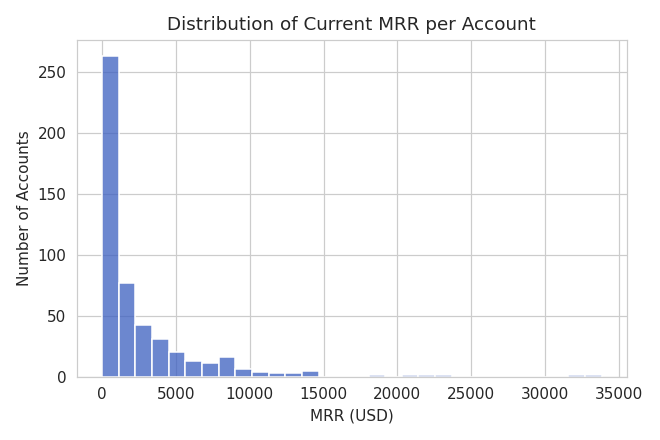

In [ ]:
plt.figure(figsize=(7,4))sns.histplot(master['mrr_amount'].dropna(), bins=30, color='#3b5fc0')plt.title('Distribution of Current MRR per Account')plt.xlabel('MRR (USD)'); plt.ylabel('Number of Accounts')plt.tight_layout()plt.show()

MRR is **right-skewed**: most accounts pay a relatively small MRR, with a long tail of high-value Enterprise accounts. This is typical of B2B SaaS revenue.

**Q: Does MRR differ by plan tier?**

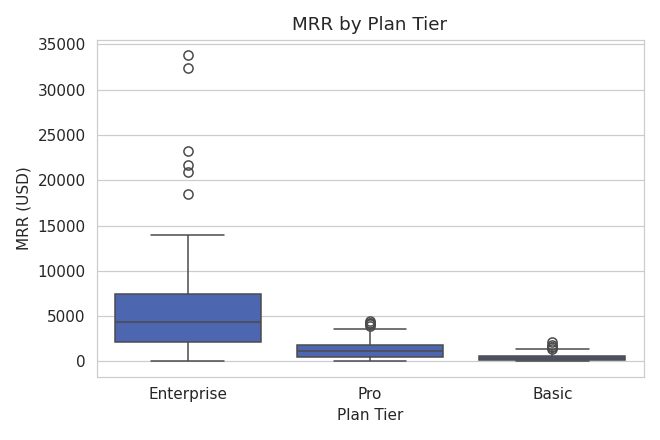

In [ ]:
plt.figure(figsize=(7,4))order = master.groupby('current_plan_tier')['mrr_amount'].median().sort_values(ascending=False).indexsns.boxplot(data=master, x='current_plan_tier', y='mrr_amount', order=order, color='#3b5fc0')plt.title('MRR by Plan Tier'); plt.xlabel('Plan Tier'); plt.ylabel('MRR (USD)')plt.tight_layout()plt.show()

**Q: How are accounts spread across industries?**

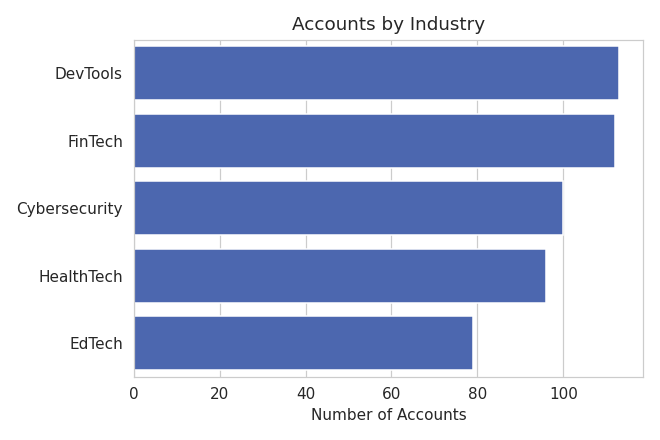

In [ ]:
plt.figure(figsize=(7,4))counts = master['industry'].value_counts()sns.barplot(x=counts.values, y=counts.index, color='#3b5fc0')plt.title('Accounts by Industry'); plt.xlabel('Number of Accounts'); plt.ylabel('')plt.tight_layout()plt.show()

**Q: How is total product usage distributed?**

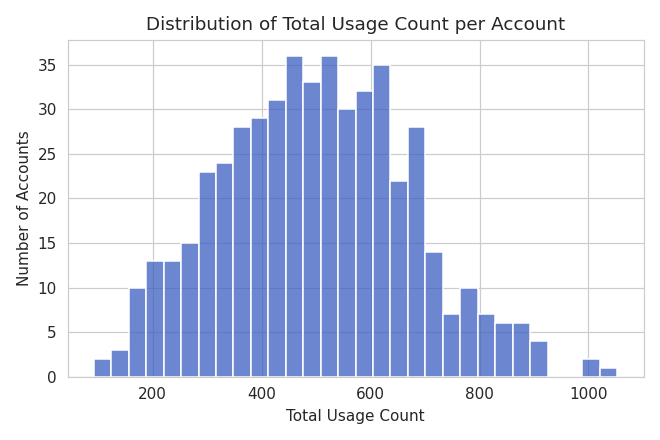

In [ ]:
plt.figure(figsize=(7,4))sns.histplot(master['total_usage_count'], bins=30, color='#3b5fc0')plt.title('Distribution of Total Usage Count per Account')plt.xlabel('Total Usage Count'); plt.ylabel('Number of Accounts')plt.tight_layout()plt.show()

**Q: Which features get used the most?**

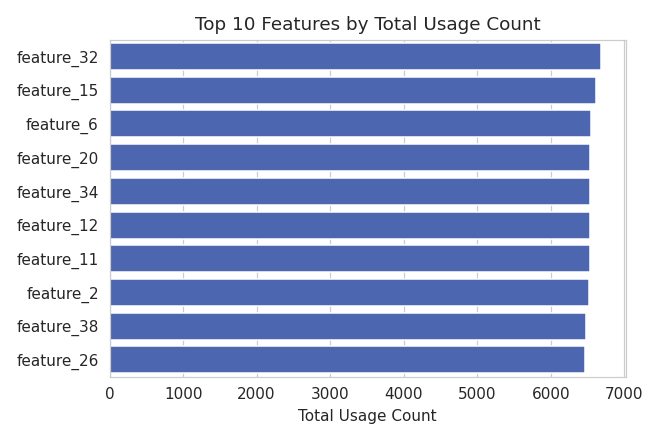

In [ ]:
feat = usage_acc.groupby('feature_name')['usage_count'].sum().sort_values(ascending=False).head(10)plt.figure(figsize=(7,4))sns.barplot(x=feat.values, y=feat.index, color='#3b5fc0')plt.title('Top 10 Features by Total Usage Count')plt.xlabel('Total Usage Count'); plt.ylabel('')plt.tight_layout()plt.show()

**Q: How does usage relate to MRR, and does that differ for churned customers?**

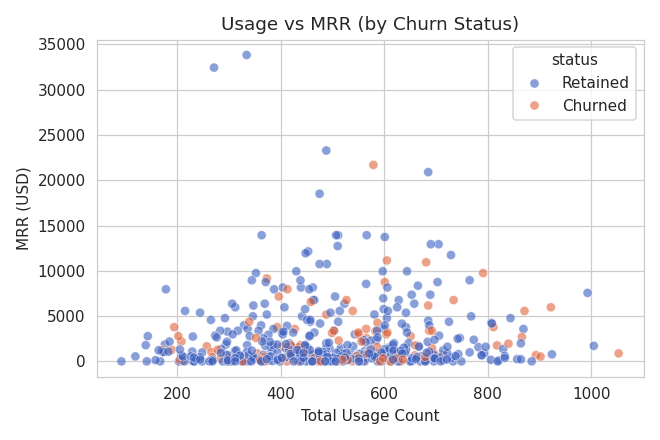

In [ ]:
plt.figure(figsize=(7,4))sns.scatterplot(data=master, x='total_usage_count', y='mrr_amount', hue='status', alpha=0.6, palette=['#3b5fc0','#e0623a'])plt.title('Usage vs MRR (by Churn Status)'); plt.xlabel('Total Usage Count'); plt.ylabel('MRR (USD)')plt.tight_layout()plt.show()

There is no obvious visual separation between churned (orange) and retained (blue) accounts based on usage and MRR alone - both groups are spread across the same range. We test this more formally with statistics in Notebook 2.

## Summary of Notebook 1
- All 5 tables load cleanly with no duplicate rows and consistent primary/foreign keys.
- Missing values are limited to fields that are legitimately optional (open subscriptions, unanswered CSAT surveys, blank churn feedback).
- We built one **account-level master table** (`master_account_table.csv`) that joins accounts, current subscription, rolled-up usage, and rolled-up support activity - this is the table used throughout the rest of the project.
- Simple rule-based Low/Medium/High segments were added for usage and MRR.
- Initial EDA shows a right-skewed MRR distribution driven by plan tier, and no obvious visual usage/MRR difference between churned and retained accounts (investigated statistically in Notebook 2).